In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg
/kaggle/input/d

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg
/kaggle/input/d

In [4]:
csv_path = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv"

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (11076, 9)

Columns:
Index(['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish',
       'aspectOfHand', 'imageName', 'irregularities'],
      dtype='object')


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [5]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
print(df.describe(include='all'))

Shape: (11076, 9)

Data Types:
id                 int64
age                int64
gender            object
skinColor         object
accessories        int64
nailPolish         int64
aspectOfHand      object
imageName         object
irregularities     int64
dtype: object

Missing Values:
id                0
age               0
gender            0
skinColor         0
accessories       0
nailPolish        0
aspectOfHand      0
imageName         0
irregularities    0
dtype: int64

Duplicate Rows:
0

Summary Statistics:
                  id           age  gender skinColor   accessories  \
count   1.107600e+04  11076.000000   11076     11076  11076.000000   
unique           NaN           NaN       2         4           NaN   
top              NaN           NaN  female    medium           NaN   
freq             NaN           NaN    7109      6495           NaN   
mean    2.031043e+05     22.494583     NaN       NaN      0.289906   
std     1.086731e+06      6.918974     NaN       NaN      0.

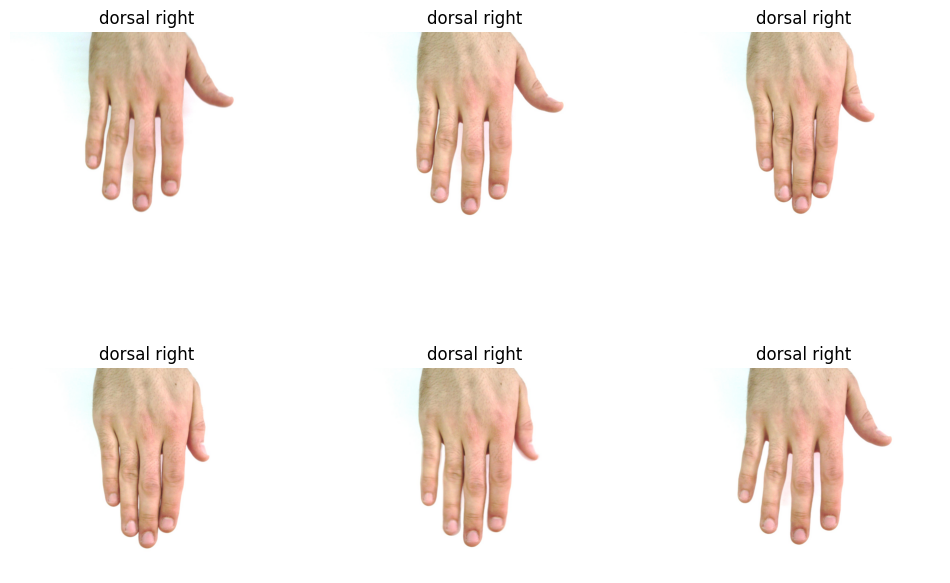

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_folder = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands"

plt.figure(figsize=(12,8))

for i in range(6):
    img_name = df.iloc[i]['imageName']
    img_path = os.path.join(image_folder, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(df.iloc[i]['aspectOfHand'])
    plt.axis('off')

plt.show()

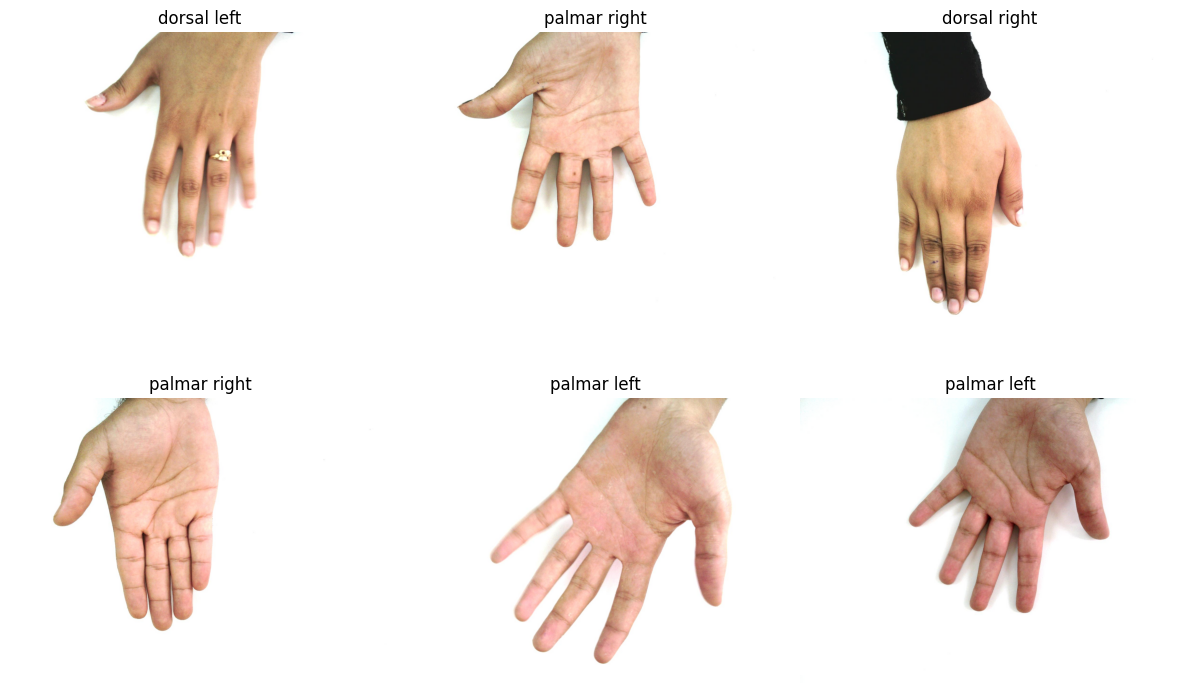

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample = df.sample(6, random_state=42)

image_folder = "/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands"

plt.figure(figsize=(12,8))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(os.path.join(image_folder, row["imageName"]))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(row["aspectOfHand"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
img = Image.open(os.path.join(image_folder, df.iloc[0]['imageName']))
print("Image Size:", img.size)

Image Size: (1600, 1200)


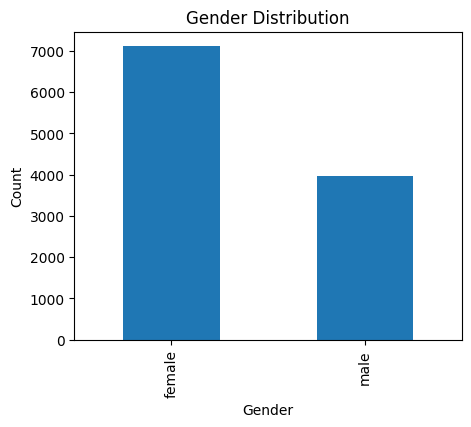

In [9]:
import matplotlib.pyplot as plt

df['gender'].value_counts().plot(kind='bar', figsize=(5,4))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

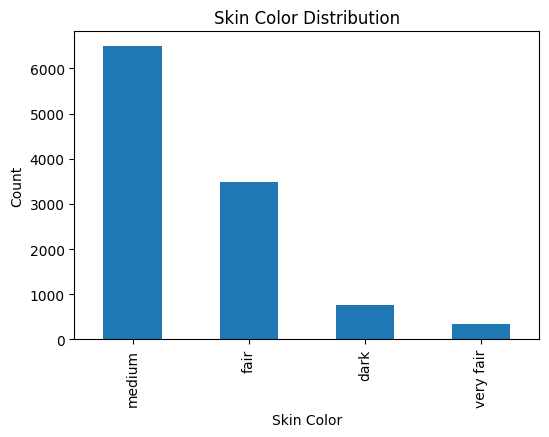

In [10]:
df['skinColor'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Skin Color Distribution")
plt.xlabel("Skin Color")
plt.ylabel("Count")
plt.show()

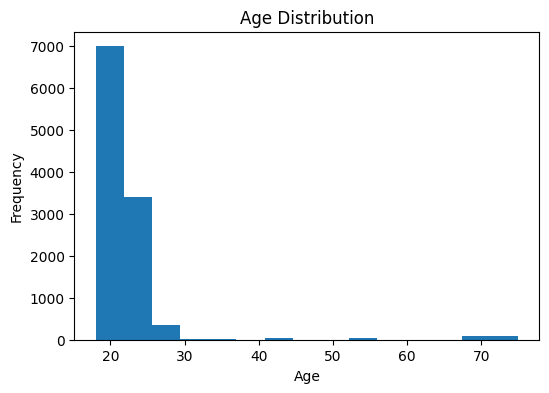

In [11]:
df['age'].plot(kind='hist', bins=15, figsize=(6,4))
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

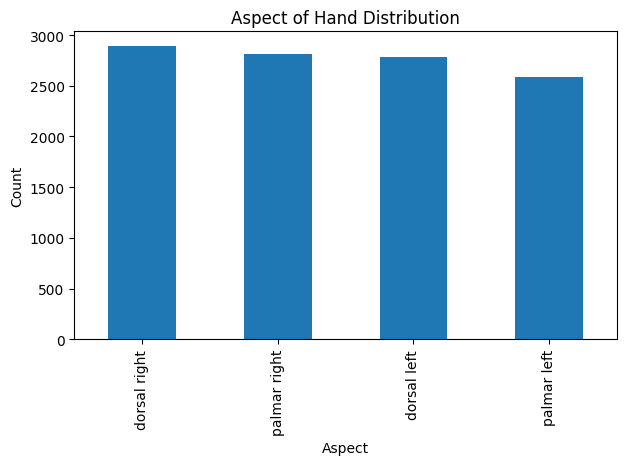

In [12]:
df['aspectOfHand'].value_counts().plot(kind='bar', figsize=(7,4))
plt.title("Aspect of Hand Distribution")
plt.xlabel("Aspect")
plt.ylabel("Count")
plt.show()

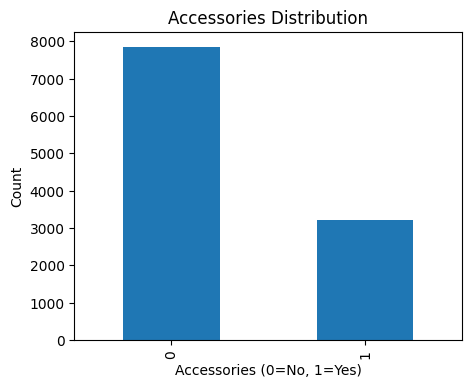

In [13]:
df['accessories'].value_counts().plot(kind='bar', figsize=(5,4))
plt.title("Accessories Distribution")
plt.xlabel("Accessories (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

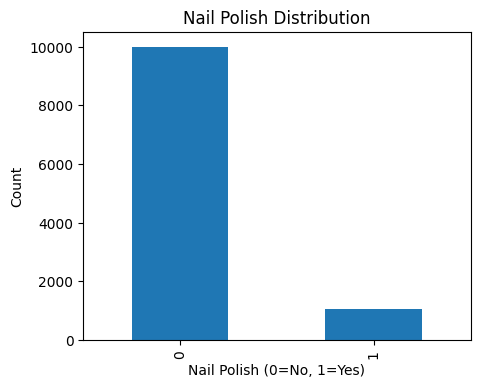

In [14]:
df['nailPolish'].value_counts().plot(kind='bar', figsize=(5,4))
plt.title("Nail Polish Distribution")
plt.xlabel("Nail Polish (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

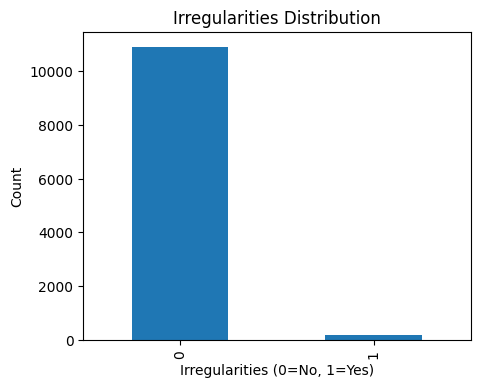

In [15]:
df['irregularities'].value_counts().plot(kind='bar', figsize=(5,4))
plt.title("Irregularities Distribution")
plt.xlabel("Irregularities (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()